In [49]:
# Importo librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [51]:
# Lectura de dataset y visualización de las primeras 5 filas
df = pd.read_csv('soja_clima_1981_2023.csv')
df.head()

,provincia_nombre,anio,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,precipitacion_total,temperatura_media,humedad_relativa
0,Buenos Aires,1981,462300,460900,924500,2005.858104,805.88,15.35,71.83
1,Buenos Aires,1982,650000,648100,950000,1465.823175,844.86,15.28,71.62
2,Buenos Aires,1983,715000,713000,1670000,2342.215989,908.29,14.75,73.22
3,Buenos Aires,1984,830000,825000,1600000,1939.393939,924.56,14.33,75.99
4,Buenos Aires,1985,851500,849350,1988000,2340.613410,809.75,15.42,70.21


In [53]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   provincia_nombre         630 non-null    object 
 1   anio                     630 non-null    int64  
 2   superficie_sembrada_ha   630 non-null    int64  
 3   superficie_cosechada_ha  630 non-null    int64  
 4   produccion_tm            630 non-null    int64  
 5   rendimiento_kgxha        627 non-null    float64
 6   precipitacion_total      630 non-null    float64
 7   temperatura_media        630 non-null    float64
 8   humedad_relativa         630 non-null    float64
dtypes: float64(4), int64(4), object(1)
memory usage: 44.4+ KB


In [55]:
# Verificación de valores nulos
df.isnull().sum()

provincia_nombre           0
anio                       0
superficie_sembrada_ha     0
superficie_cosechada_ha    0
produccion_tm              0
rendimiento_kgxha          3
precipitacion_total        0
temperatura_media          0
humedad_relativa           0
dtype: int64

In [57]:
# Elimino nulos en rendimiento
df = df.dropna(subset=['rendimiento_kgxha'])

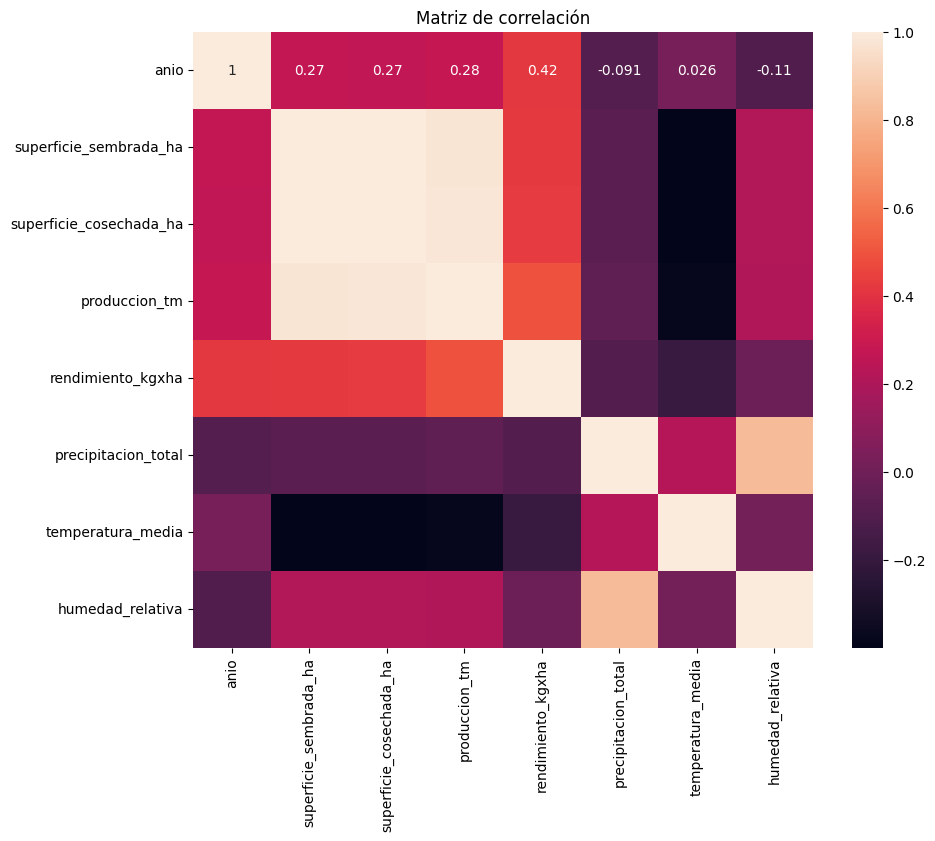

In [59]:
# Mapa de correlación de variables
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

In [60]:
# Convierto la variable "provincia" en dummies
df_modelo = pd.get_dummies(
    df,
    columns=['provincia_nombre'],
    drop_first=True
)

In [63]:
df_modelo.head()

,anio,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,precipitacion_total,temperatura_media,humedad_relativa,provincia_nombre_Catamarca,provincia_nombre_Chaco,...,provincia_nombre_Entre Ríos,provincia_nombre_Formosa,provincia_nombre_Jujuy,provincia_nombre_La Pampa,provincia_nombre_Misiones,provincia_nombre_Salta,provincia_nombre_San Luis,provincia_nombre_Santa Fe,provincia_nombre_Santiago del Estero,provincia_nombre_Tucumán
0,1981,462300,460900,924500,2005.858104,805.88,15.35,71.83,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1982,650000,648100,950000,1465.823175,844.86,15.28,71.62,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1983,715000,713000,1670000,2342.215989,908.29,14.75,73.22,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1984,830000,825000,1600000,1939.393939,924.56,14.33,75.99,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1985,851500,849350,1988000,2340.613410,809.75,15.42,70.21,False,False,...,False,False,False,False,False,False,False,False,False,False


In [65]:
# Defino variables predictoras y objetivo
X = df_modelo.drop(columns=['rendimiento_kgxha', 'superficie_cosechada_ha', 'produccion_tm'])
y = df_modelo['rendimiento_kgxha']

In [67]:
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## K-NN

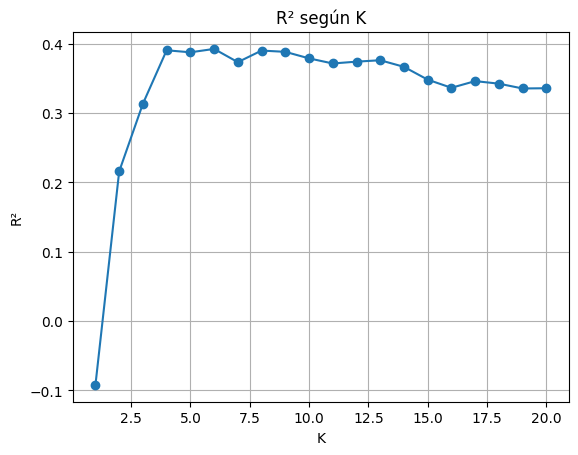

In [71]:
# Gráfico r2 según k
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

k_values = range(1, 21)
scores = []

for k in k_values:
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train)

    pred = modelo.predict(X_test_scaled)

    scores.append(r2_score(y_test, pred))

plt.plot(k_values, scores, marker='o')
plt.xlabel('K')
plt.ylabel('R²')
plt.title('R² según K')
plt.grid(True)
plt.show()

In [72]:
# Modelo
knn = KNeighborsRegressor(n_neighbors=4)

knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred = knn.predict(X_test_scaled)

In [75]:
# Métricas
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.39061647769547814
MAE: 357.02277102625135
RMSE: 463.89215011623617


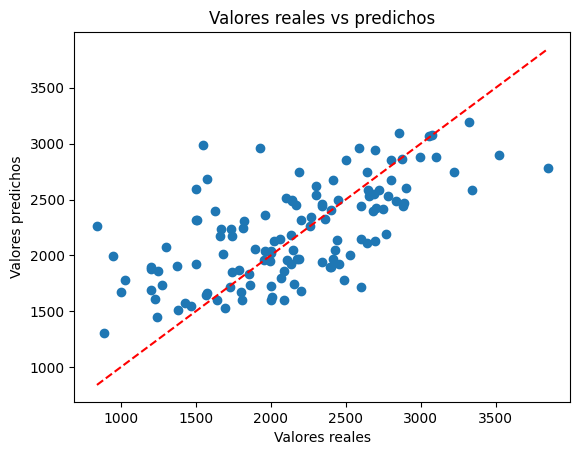

In [77]:
# Gráfico valores reales vs predichos
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

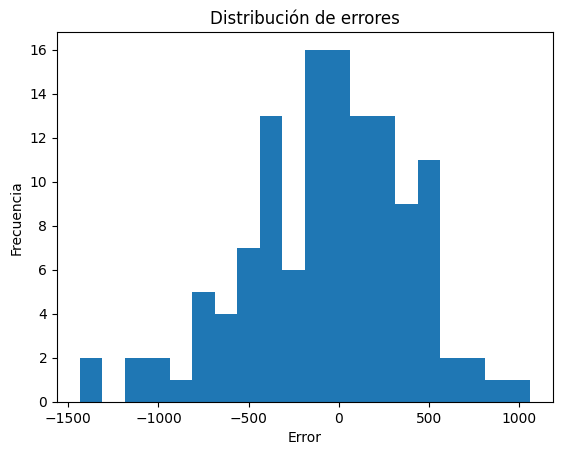

In [79]:
# Gráfico distribución de errores
errores = y_test - y_pred

plt.hist(errores, bins=20)
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores")
plt.show()

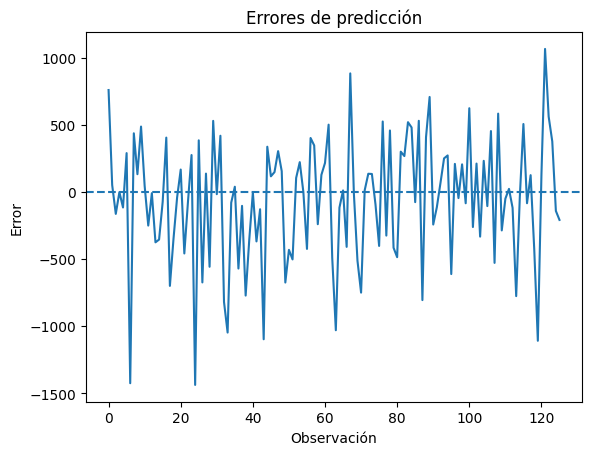

In [81]:
# Gráfico de errores de predicción
plt.plot(errores.values)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Observación")
plt.ylabel("Error")
plt.title("Errores de predicción")
plt.show()

## Regresión Lineal

In [84]:
# Modelo
modelo_lr = LinearRegression()

modelo_lr.fit(X_train_scaled, y_train)


LinearRegression()

In [86]:
# Predicciones
y_pred = modelo_lr.predict(X_test_scaled)

In [88]:
# Métricas
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.369066335855048
MAE: 365.7036591360044
RMSE: 472.02339076628317


## Árbol de Decisión

In [105]:
# Modelo
arbol = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

arbol.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [107]:
# Predicciones
y_pred = arbol.predict(X_test)

In [109]:
# Métricas
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.2639872050800339
MAE: 407.9820104366174
RMSE: 509.8170460471781


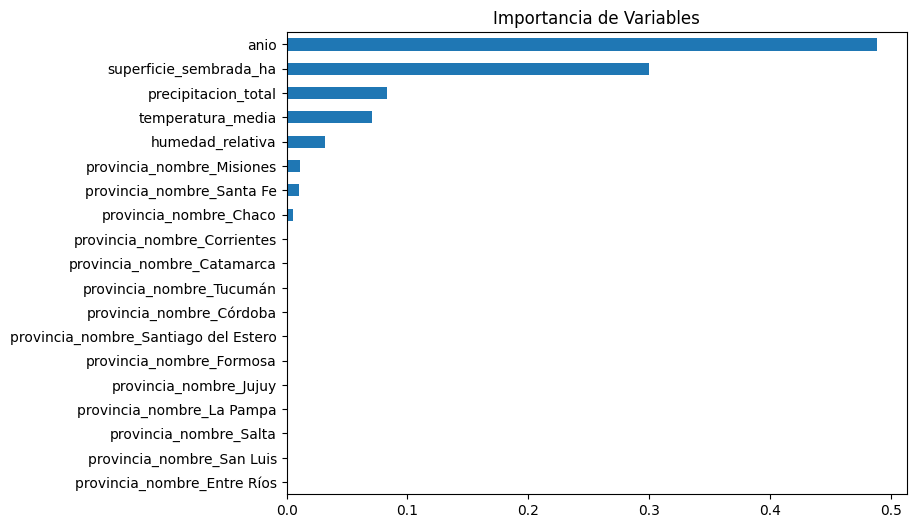

In [111]:
# Importancia de variables
importancias = pd.Series(
    arbol.feature_importances_,
    index=X.columns
)

importancias.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title('Importancia de Variables')
plt.show()

## SVR

In [114]:
# Modelo
svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale'
)

svr.fit(X_train_scaled, y_train)

SVR(C=100)

In [116]:
# Predicciones
y_pred = svr.predict(X_test_scaled)

In [118]:
# Métricas
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.3434155465162122
MAE: 375.77081398002247
RMSE: 481.52292434278564


## Concluisones
De acuerdo a las métricas obtenidas, el modelo K-Nearest Neighbors presentó el mejor desempeño.
Los resultados indican que las variables productivas y climáticas incorporadas poseen capacidad explicativa sobre el rendimiento del cultivo.

Si bien el nivel de predicción alcanzado es moderado, debe considerarse que el rendimiento agrícola es un fenómeno complejo influenciado por numerosos factores que no fueron incluidos en este estudio. Entre ellos pueden mencionarse las características físicas y químicas del suelo, las variedades de soja utilizadas, las prácticas de manejo agronómico, la fertilización aplicada, la incidencia de plagas y enfermedades, así como la ocurrencia de eventos climáticos extremos.

A pesar de estas limitaciones, el trabajo permitió demostrar la aplicabilidad de técnicas de aprendizaje automático en el análisis de problemas agropecuarios y evidenció la importancia de las variables climáticas en la productividad agrícola. Además, se logró integrar conocimientos vinculados a la ciencia de datos y a las ciencias ambientales, obteniendo una herramienta capaz de generar estimaciones útiles para el estudio y la planificación de la producción de soja.

Como líneas futuras de investigación, se propone incorporar nuevas variables explicativas, realizar un ajuste más exhaustivo de hiperparámetros y evaluar algoritmos más avanzados, tales como Random Forest, Gradient Boosting o XGBoost, con el objetivo de mejorar la capacidad predictiva y profundizar el análisis de los factores que determinan el rendimiento del cultivo.